# 01 通用原子柱定位、自动聚类与人工复核

本 notebook 面向任意二维 STEM / 相位 / 反差类原子分辨图像，不预设材料体系、元素名称或成像通道名称。推荐顺序为：

1. 读取一个或多个已配准通道。
2. 在一个或多个通道上寻找原子柱候选点。
3. 人工复核候选点。
4. 在 candidate 坐标周围提取局部图像特征并自动聚类。
5. 用户按实验背景复核类别。
6. 按已复核类别分别做亚像素精修并保存结果。

重要提醒：自动聚类得到的是图像衬度和局部形貌特征类别，不等价于元素鉴定。类别名称、颜色和物理解释应由用户结合样品结构、成像条件和其他实验信息决定。

In [1]:
from pathlib import Path
import sys

notebook_file = globals().get('__vsc_ipynb_file__')
PROJECT_ROOT = Path(notebook_file).resolve().parent if notebook_file else Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_SRC = str(PROJECT_ROOT / 'src')
if PROJECT_SRC in sys.path:
    sys.path.remove(PROJECT_SRC)
sys.path.insert(0, PROJECT_SRC)
for module_name in list(sys.modules):
    if module_name == 'em_atom_workbench' or module_name.startswith('em_atom_workbench.'):
        del sys.modules[module_name]

import matplotlib.pyplot as plt
from IPython.display import display

from em_atom_workbench import (
    AtomColumnClassificationConfig,
    CurationConfig,
    DetectionConfig,
    PixelCalibration,
    RefinementConfig,
    save_checkpoint,
)
from em_atom_workbench.plotting import launch_refinement_napari_viewer
from em_atom_workbench.notebook_workflows import (
    display_notebook_result,
    initialize_generic_classification_session,
    run_atom_column_classification,
    run_generic_candidate_detection,
    run_generic_curation,
    run_generic_refinement,
    review_generic_candidates,
    save_final_checkpoint_if_requested,
    show_atom_column_class_review,
)

plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

RESULT_ROOT = PROJECT_ROOT / 'results'
RESULT_ROOT.mkdir(exist_ok=True)
session = None
active_path = RESULT_ROOT / '_active_session.pkl'

## 1. 通道输入参数

这一格只填写图像通道、主显示通道、dataset 读取位置和手动像素标定。改完这里后重跑下一格即可重新初始化 session。

In [2]:
# A. 通道输入参数
# =========================
# CHANNELS：任意通道名到图像路径的映射。单通道也写成字典。
# - 键是你希望在后续表格和图例中看到的通道名。
# - 值是图像路径，支持 tif/mrc/h5/dm 等当前 io 模块支持的格式。
# - 如果留空 {}，会生成一个两通道 synthetic demo，仅用于检查流程。
CHANNELS = {
    'Ptycho_DW1': "D:/LIANGKUAN/PolyU-PhD/Reserch/HfO2/Ptycho/1_Cut.dm4",
    # 'channel_1': 'D:/path/to/second_registered_image.tif',
}

# PRIMARY_CHANNEL：默认显示、预览和坐标基准通道；必须是 CHANNELS 的键。
# 若 CHANNELS 留空使用 synthetic demo，则默认会自动使用 'channel_0'。
PRIMARY_CHANNEL = 'Ptycho_DW1'

# CHANNEL_CONTRAST_MODES：每个通道的局部极值类型。
# - 'bright_peak'：原子柱表现为亮峰。
# - 'dark_dip'：原子柱表现为暗谷，特征提取时会自动反号使其成为正响应。
# - 'mixed_contrast'：检测时同时尝试亮峰和暗谷。
CHANNEL_CONTRAST_MODES = {
    'Ptycho_DW1': 'bright_peak',
    # 'channel_1': 'bright_peak',
}

# CHANNEL_DATASET_INDICES：当某个文件里有多个 dataset 时指定读取哪一个；普通 2D 图像可设为 None。
CHANNEL_DATASET_INDICES = {
    'Ptycho_DW1': None,
    # 'channel_1': None,
}

# MANUAL_CALIBRATION：当图像文件没有可靠像素标定时手动填写。
# 例如 PixelCalibration(size=0.02, unit='nm', source='manual')；不需要时设为 None。
MANUAL_CALIBRATION = None

# SYNTHETIC_RNG_SEED：CHANNELS 留空时 synthetic demo 的随机种子；只影响演示数据。
SYNTHETIC_RNG_SEED = 11

# =========================

## 图像导入与 session 初始化

这一步只负责创建新的 `AnalysisSession` 并记录当前 workflow。多通道输入默认已经空间配准且 shape 一致。

,field,value
0,session_name,1_cut
1,input_path,D:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\Ptycho\1_C...
2,dataset_index,None
3,pixel_size,0.015545
4,unit,nm
5,workflow_mode,atom_column_classification
6,current_stage,loaded
7,channel_count,1
8,candidate_count,0
9,refined_count,0


,key,value
0,metadata,"{'_HyperSpy': {'Folding': {'unfolded': False, ..."
1,original_metadata,"{'root': {}, 'ApplicationBounds': [0, 0, 887, ..."
2,dataset_index,None


,channel,is_primary,input_path,dataset_index,contrast_mode,raw_shape
0,Ptycho_DW1,True,D:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\Ptycho\1_C...,None,bright_peak,"(380, 305)"


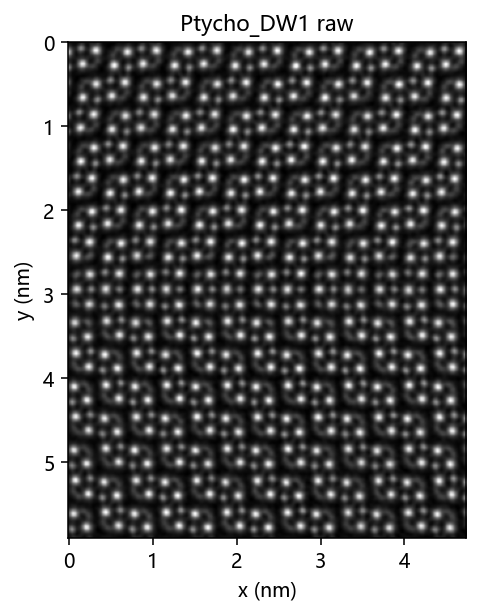

session: 1_cut
workflow_mode: atom_column_classification
current_stage: loaded
primary_channel: Ptycho_DW1
active_session: D:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\_active_session.pkl


In [3]:
result = initialize_generic_classification_session(
    result_root=RESULT_ROOT,
    channels=CHANNELS,
    primary_channel=PRIMARY_CHANNEL,
    channel_contrast_modes=CHANNEL_CONTRAST_MODES,
    channel_dataset_indices=CHANNEL_DATASET_INDICES,
    manual_calibration=MANUAL_CALIBRATION,
    synthetic_rng_seed=SYNTHETIC_RNG_SEED,
)
session = result.session
active_path = result.active_path
display_notebook_result(result)

## 2. 候选点检测参数

这一格只调整候选原子柱检测。每个通道可以使用独立的平滑、阈值、SNR、边缘排除和去重点距离。

In [32]:
# B. 候选点检测参数
# =========================
# DETECTION_CONFIGS_BY_CHANNEL：每个参与检测的通道各自一套参数。
# - gaussian_sigma：检测前高斯平滑强度；噪声大可增大，过大会抹平弱柱。
# - min_distance：两个候选点允许的最小像素距离；太小会重复检出，太大会漏近邻。
# - threshold_abs：绝对阈值；None 表示不用绝对阈值。
# - threshold_rel：相对阈值，按图像动态范围筛选局部极值。
# - min_prominence：中心响应相对局部背景的最小突起强度。
# - min_snr：局部信噪比下限；噪声图像中建议提高。
# - edge_margin：忽略离图像边缘多少像素内的点。
# - patch_radius：计算局部背景、prominence 和 SNR 的半窗口半径。
# - dedupe_radius_px：同一通道内部去重点半径。
DETECTION_CONFIGS_BY_CHANNEL = {
    'Ptycho_DW1': DetectionConfig(
        contrast_mode=CHANNEL_CONTRAST_MODES.get('Ptycho_DW1', 'bright_peak'),
        gaussian_sigma=0.001,
        min_distance=1,
        threshold_abs=None,
        threshold_rel=0.0001,
        min_prominence=0.005,
        min_snr=0.005,
        edge_margin=2,
        patch_radius=1,
        dedupe_radius_px=1,
    ),
    # 'channel_1': DetectionConfig(...),
}

# MERGE_DEDUPE_RADIUS_PX：多通道检测结果合并时的去重点半径。
# 多个通道在同一原子柱附近检出的点会合并为一个候选点，并记录 detected_from_channels。
MERGE_DEDUPE_RADIUS_PX = 4.0

## 候选原子柱检测

这一步可在一个或多个通道上分别寻找局部极值，然后按空间距离合并为通用 `atom_column` 候选点。此阶段不做类别判断。

,field,value
0,session_name,1_cut
1,input_path,D:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\Ptycho\1_C...
2,dataset_index,None
3,pixel_size,0.015545
4,unit,nm
5,workflow_mode,atom_column_classification
6,current_stage,detected
7,channel_count,1
8,candidate_count,944
9,refined_count,0


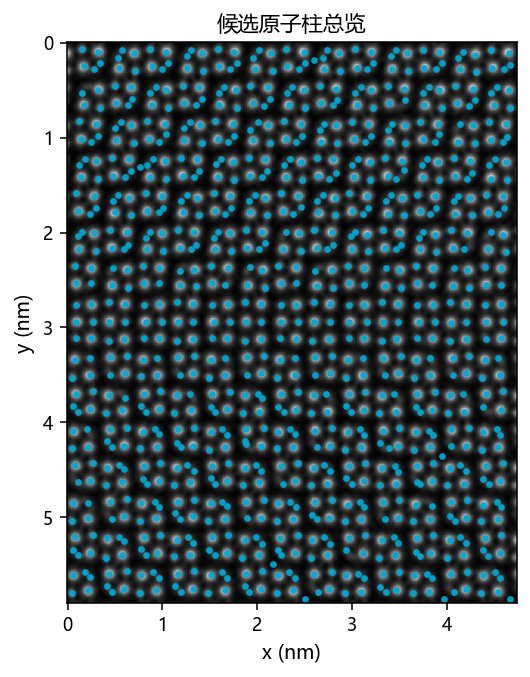

candidate_count: 944


In [33]:
result = run_generic_candidate_detection(
    session,
    result_root=RESULT_ROOT,
    detection_configs_by_channel=DETECTION_CONFIGS_BY_CHANNEL,
    merge_dedupe_radius_px=MERGE_DEDUPE_RADIUS_PX,
)
session = result.session
active_path = result.active_path
display_notebook_result(result)

## 3. 候选点人工复核参数

这一格只控制检测后的 napari 候选点复核。用户需要在 napari 中补上漏检原子柱、删掉误检点、移动偏离中心的点，然后关闭窗口写回 session。

In [ ]:
# OPEN_CANDIDATE_REVIEW_VIEWER：是否打开 napari 候选点人工复核窗口。
# 这是精修前的强制确认步骤；保持 True 并运行下一格，关闭 napari 后会写回 candidate_points。
OPEN_CANDIDATE_REVIEW_VIEWER = True

# CANDIDATE_REVIEW_IMAGE_CHANNEL：候选点复核时显示哪个通道；多通道数据可改为任意已加载通道名。
CANDIDATE_REVIEW_IMAGE_CHANNEL = PRIMARY_CHANNEL

# CANDIDATE_REVIEW_IMAGE_KEY：复核时显示 'processed' 或 'raw' 图像。
# 'processed' 会使用当前通道的处理后图像和对应 origin；'raw' 直接显示原始图像。
CANDIDATE_REVIEW_IMAGE_KEY = 'processed'

# CANDIDATE_REVIEW_POINT_SIZE：napari 中候选点标记大小；图像很大或点很密时可适当调小。
CANDIDATE_REVIEW_POINT_SIZE = 6.0

## 候选点 napari 人工复核

这一步只确认“所有原子柱位置是否被识别”，不做类别、元素或成像通道物理解释。完成后 stage 会变为 `candidate_reviewed`，随后进入初始聚类。

In [ ]:
result = review_generic_candidates(
    session,
    result_root=RESULT_ROOT,
    open_viewer=OPEN_CANDIDATE_REVIEW_VIEWER,
    image_channel=CANDIDATE_REVIEW_IMAGE_CHANNEL,
    image_key=CANDIDATE_REVIEW_IMAGE_KEY,
    point_size=CANDIDATE_REVIEW_POINT_SIZE,
)
session = result.session or session
if result.active_path is not None:
    active_path = result.active_path
display_notebook_result(result)

## 4. 特征提取与聚类参数

这一格集中调整分类真正使用的图像特征、缩放方式、聚类算法、类别数、置信度阈值，以及用户命名和配色。自动聚类得到的是图像特征类别，不等价于元素鉴定。

In [36]:
# D. 特征提取参数
# =========================
# FEATURE_CHANNELS：参与分类的通道列表；None 表示使用 session 中所有通道。
FEATURE_CHANNELS = None

# FEATURE_PATCH_RADII：每个原子柱周围提取特征的半窗口半径。
# 可写整数，也可写 {'default': 6, 'channel_0': 8} 覆盖某个通道。
FEATURE_PATCH_RADII = {'default': 2}

# FEATURES_ENABLED：启用哪些特征进入聚类。
# - center_intensity：中心像素响应。
# - prominence：中心响应减局部背景。
# - local_snr：prominence 除以局部背景噪声。
# - integrated_intensity：patch 内扣背景后的积分响应。
# - mean/std：patch 均值和标准差。
# - quantiles：patch 分位数，配合 QUANTILES 使用。
# - radial_profile：径向分箱均值，配合 RADIAL_PROFILE_BINS 使用。
FEATURES_ENABLED = (
    'center_intensity',
    # 'prominence',
    # 'local_snr',
    # 'integrated_intensity',
    # 'mean',
    # 'std',
    # 'quantiles',
)

# BACKGROUND_MODE：局部背景估计方式。
# - 'border_median'：patch 边界像素中位数，默认稳健。
# - 'ring_median'：当前等价于边界环中位数，语义上用于环形背景。
# - 'local_quantile'：patch 低分位数，适合背景起伏较大时尝试。
BACKGROUND_MODE = 'border_median'

# FEATURE_CHANNEL_WEIGHTS：多通道特征权重；在特征缩放后应用。
# 数值越大，该通道对聚类距离的影响越大。
FEATURE_CHANNEL_WEIGHTS = {
    # 'channel_0': 1.0,
    # 'channel_1': 1.0,
}

# QUANTILES：FEATURES_ENABLED 包含 quantiles 时提取的分位数。
QUANTILES = (0.10, 0.25, 0.50, 0.75, 0.90)

# RADIAL_PROFILE_BINS：FEATURES_ENABLED 包含 radial_profile 时径向分箱数量。
RADIAL_PROFILE_BINS = 3

# SOURCE_TABLE_FOR_CLASSIFICATION：分类从哪张坐标表提取特征。
# 本 notebook 先分类再按类别精修，因此默认从人工复核后的 candidate_points 提取。
SOURCE_TABLE_FOR_CLASSIFICATION = 'candidate'

# =========================

# E. 自动聚类参数
# =========================
# N_CLASSES：用户期望类别数；建议先根据图像衬度直方图和结构先验明确填写。
N_CLASSES = 3

# AUTO_SUGGEST_N_CLASSES：是否用 silhouette 分数自动建议类别数。
# 开启后会在 N_CLASSES_RANGE 内搜索；建议只作为参考，不替代人工判断。
AUTO_SUGGEST_N_CLASSES = False

# N_CLASSES_RANGE：自动建议类别数时搜索的最小和最大类别数。
N_CLASSES_RANGE = (2, 5)

# CLUSTER_METHOD：聚类方法。
# - 'gaussian_mixture'：默认，适合类别呈椭球分布并可给出概率置信度。
# - 'kmeans'：快速稳定，适合近似球形类别。
# - 'agglomerative'：层次聚类，适合点数不大且类别形状不规则时尝试。
# - 'dbscan'：密度聚类，不需要 N_CLASSES，但需要调 eps 和 min_samples。
CLUSTER_METHOD = 'gaussian_mixture'

# FEATURE_SCALING：特征缩放方式。
# - 'robust'：用中位数和四分位距，抗异常值，默认推荐。
# - 'standard'：均值方差标准化。
# - 'minmax'：压缩到 0-1。
# - 'none'：不缩放，仅在特征量纲本来可比时使用。
FEATURE_SCALING = 'robust'

# OUTLIER_MODE：异常点处理策略。
# - 'none'：不标记异常点。
# - 'confidence'：低于 CONFIDENCE_THRESHOLD 的点设为 unclassified。
# - 'small_class'：小于 MIN_CLASS_SIZE 的类别设为 unclassified。
# - 'confidence_or_small_class'：同时启用两种规则。
OUTLIER_MODE = 'confidence'

# MIN_CLASS_SIZE：小类别最少点数；低于该值时建议人工检查或合并。
MIN_CLASS_SIZE = 3

# CONFIDENCE_THRESHOLD：类别置信度下限；越高越保守，低置信度点更容易被标为 unclassified。
CONFIDENCE_THRESHOLD = 0.0

# RANDOM_STATE：随机种子，控制 GMM/KMeans 可重复性。
RANDOM_STATE = 0

# MAX_ITER：GMM/KMeans 最大迭代次数；复杂数据可适当增大。
MAX_ITER = 300

# N_INIT：GMM/KMeans 多次初始化次数；越大越稳但更慢。
N_INIT = 10

# DBSCAN_EPS / DBSCAN_MIN_SAMPLES：CLUSTER_METHOD='dbscan' 时使用。
# eps 控制邻域半径，min_samples 控制形成核心簇所需最少点数。
DBSCAN_EPS = 0.8
DBSCAN_MIN_SAMPLES = 5

# =========================

# CLASS_NAME_MAP：把自动生成的 class_0/class_1/... 改成你自己的类别名。
# 类别名可以是任意中文或英文，但不要把自动聚类结果直接等同于元素鉴定。
CLASS_NAME_MAP = {
    # 0: '类别_A',
    # 1: '类别_B',
    # 2: '类别_C',
}

# CLASS_COLOR_MAP：每类在图上的颜色，支持十六进制颜色字符串。
CLASS_COLOR_MAP = {
    # 0: '#00a5cf',
    # 1: '#f18f01',
    # 2: '#7a5195',
}

# SAVE_CLASSIFIED_CHECKPOINT：是否在分类完成、最终 curation 前保存一个中间 checkpoint。
SAVE_CLASSIFIED_CHECKPOINT = True
CLASSIFIED_CHECKPOINT_FILENAME = '01_classified_atom_columns.pkl'

## 特征提取与自动聚类

这一步围绕人工复核后的 candidate 坐标提取局部图像特征，并根据用户设置的聚类参数自动分组。输出类别是图像特征类别，不能直接当作元素标签。

,field,value
0,session_name,1_cut
1,input_path,D:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\Ptycho\1_C...
2,dataset_index,None
3,pixel_size,0.015545
4,unit,nm
5,workflow_mode,atom_column_classification
6,current_stage,classified
7,channel_count,1
8,candidate_count,944
9,refined_count,0


,class_id,class_name,count,mean_confidence
0,0,class_0,335,0.999466
1,1,class_1,206,0.999576
2,2,class_2,403,1.000000


,atom_id,candidate_id,x_px,y_px,Ptycho_DW1__center_intensity
0,0,0,172.0,41.0,243.0
1,1,1,100.0,114.0,243.0
2,2,2,249.0,104.0,251.0
3,3,3,85.0,224.0,243.0
4,4,4,108.0,297.0,233.0


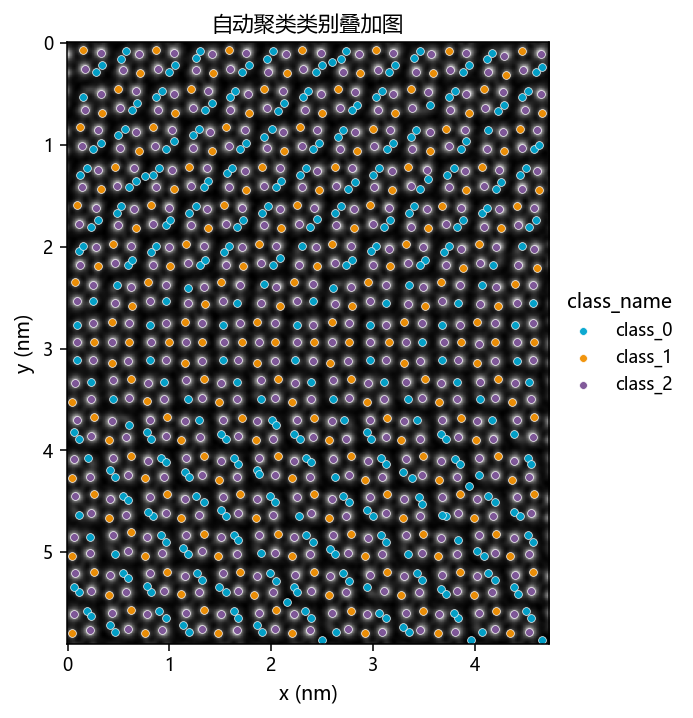

classified_count: 944
已保存分类 checkpoint: D:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\1_cut\checkpoints\01_classified_atom_columns.pkl


In [37]:
classification_config = AtomColumnClassificationConfig(
    feature_channels=FEATURE_CHANNELS,
    feature_patch_radii=FEATURE_PATCH_RADII,
    features_enabled=FEATURES_ENABLED,
    background_mode=BACKGROUND_MODE,
    feature_channel_weights=FEATURE_CHANNEL_WEIGHTS,
    quantiles=QUANTILES,
    radial_profile_bins=RADIAL_PROFILE_BINS,
    source_table=SOURCE_TABLE_FOR_CLASSIFICATION,
    n_classes=N_CLASSES,
    auto_suggest_n_classes=AUTO_SUGGEST_N_CLASSES,
    n_classes_range=N_CLASSES_RANGE,
    cluster_method=CLUSTER_METHOD,
    feature_scaling=FEATURE_SCALING,
    outlier_mode=OUTLIER_MODE,
    min_class_size=MIN_CLASS_SIZE,
    random_state=RANDOM_STATE,
    max_iter=MAX_ITER,
    n_init=N_INIT,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    dbscan_eps=DBSCAN_EPS,
    dbscan_min_samples=DBSCAN_MIN_SAMPLES,
    class_name_map=CLASS_NAME_MAP,
    class_color_map=CLASS_COLOR_MAP,
)

result = run_atom_column_classification(
    session,
    result_root=RESULT_ROOT,
    classification_config=classification_config,
    class_name_map=CLASS_NAME_MAP,
    class_color_map=CLASS_COLOR_MAP,
)
session = result.session
active_path = result.active_path
display_notebook_result(result)

if SAVE_CLASSIFIED_CHECKPOINT and session.current_stage == 'classified':
    checkpoint_path = save_checkpoint(session, RESULT_ROOT, CLASSIFIED_CHECKPOINT_FILENAME)
    print(f'已保存分类 checkpoint: {checkpoint_path}')

## 5. 人工类别复核参数

这一格只控制是否打开 napari 类别复核窗口，以及复核时点标记的显示大小。

In [40]:
# OPEN_CLASS_REVIEW_VIEWER：是否打开 napari 按类别分层复核。
# 在 viewer 中删除或移动点后，关闭窗口会写回当前 session。
OPEN_CLASS_REVIEW_VIEWER = True
CLASS_REVIEW_POINT_SIZE = 7.0

## 人工类别复核

如果打开 napari 复核，每个类别会作为独立点图层显示。你可以删除误检点、移动点，或把点拖到相应类别图层；关闭窗口后修改会写回 candidate_points。类别物理含义仍由用户自行判断。

In [41]:
result = show_atom_column_class_review(
    session,
    result_root=RESULT_ROOT,
    open_viewer=OPEN_CLASS_REVIEW_VIEWER,
    image_channel=PRIMARY_CHANNEL,
    point_size=CLASS_REVIEW_POINT_SIZE,
    source_table='candidate',
)
session = result.session or session
if result.active_path is not None:
    active_path = result.active_path
display_notebook_result(result)

Class review viewer closed and edits were applied.


## 6. 按类别精修参数

这一格只调整亚像素精修窗口、拟合宽度、允许中心漂移和拟合图像来源。默认配置适用于所有类别；`CLASS_REFINEMENT_OVERRIDES` 只覆盖指定 class_id 的部分字段。

In [49]:
# C. 精修参数
# =========================
# mode：精修策略；'adaptive_atomap' 根据近邻距离自适应窗口，'legacy' 使用固定窗口。
# fit_half_window：legacy 模式下高斯拟合半窗口半径；adaptive 模式只在无法计算近邻距离时作为兜底。
# com_half_window：高斯拟合前先做局部质心微调的半窗口半径；弱粘连柱容易被质心拉偏时可减小。
# nn_radius_fraction：adaptive 模式下窗口半径占最近邻距离的比例；越大越容易包含邻近峰和背景。
# min_patch_radius_px：adaptive 窗口最小半径；太小可能没有足够像素拟合，太大可能混入邻近柱。
# max_patch_radius_px：adaptive 窗口最大半径；弱粘连/近邻密集区域建议不要过大。
# initial_sigma_px：高斯拟合初始宽度；接近实际峰宽时更容易收敛。
# min_sigma_px：允许的最小高斯宽度；过小会追逐噪声尖点。
# max_sigma_px：允许的最大高斯宽度；过大会把粘连峰或背景带拟合成宽峰。
# max_center_shift_px：硬性位移上限；精修坐标超出该距离时会回退到复核后的 candidate 坐标。
# max_nfev：单次高斯拟合最大函数评估次数；收敛失败可增大，但会变慢。
# gaussian_retry_count：高斯拟合失败或结果不合理时，缩小窗口重新拟合的次数。
# gaussian_retry_shrink_factor：每次重试窗口缩小比例；越小收缩越快。
# sigma_ratio_limit：允许的 sigma_x/sigma_y 最大长宽比；降低可拒绝过于狭长的异常拟合。
# fit_edge_margin_px：拟合中心距离 patch 边缘的最小距离；用于拒绝跑到窗口边缘的拟合。
# gaussian_image_source：'raw' 或 'processed'；指定高斯拟合用原始图还是预处理图。
# fallback_to_quadratic：高斯失败时是否用局部二次曲面峰值兜底；通常比质心更不容易被粘连带拉偏。
# fallback_to_com：高斯和二次兜底不可用时是否用质心兜底；弱粘连柱可能被拉向亮带。
# quality_floor：quality_score 的下限；只影响质量分数，不改变精修坐标。
# overlap_trigger_px：互为近邻的两点距离小于该阈值时，尝试双高斯共享形状共同精修；None 表示关闭。
REFINEMENT_CONFIG = RefinementConfig(
    mode='adaptive_atomap',
    fit_half_window=6,
    com_half_window=4,
    nn_radius_fraction=0.38,
    min_patch_radius_px=5,
    max_patch_radius_px=14,
    initial_sigma_px=1.2,
    min_sigma_px=0.5,
    max_sigma_px=4.0,
    max_center_shift_px=3.0,
    max_nfev=4000,
    gaussian_retry_count=3,
    gaussian_retry_shrink_factor=0.9,
    sigma_ratio_limit=4.0,
    fit_edge_margin_px=1.0,
    gaussian_image_source='raw',
    fallback_to_quadratic=True,
    fallback_to_com=True,
    quality_floor=0.0,
    overlap_trigger_px=None,
)

# NN_CONTEXT_MODE：adaptive 精修计算最近邻距离和 overlap 配对时使用的上下文。
# - 'all'：默认，使用全部 candidate 点，适合跨类别粘连/邻峰会互相干扰的情况。
# - 'same_class'：只使用相同 class_id 的点；单点类别会回退到 fit_half_window/com_half_window 兜底窗口。
NN_CONTEXT_MODE = 'all'

CLASS_REFINEMENT_OVERRIDES = {
    # class_0 / O1：弱柱，距离邻峰很近，尽量只允许亚像素小修正
    0: dict(
        nn_radius_fraction=0.5,
        min_patch_radius_px=2,
        max_patch_radius_px=3,
        fit_half_window=2,
        com_half_window=1,
        initial_sigma_px=0.7,
        min_sigma_px=0.35,
        max_sigma_px=1.1,
        max_center_shift_px=0.8,
        fallback_to_quadratic=True,
        fallback_to_com=False,
        gaussian_image_source='raw',
        overlap_trigger_px=8,
    ),

    # class_1 / O2：中等亮度，较孤立，可以允许一点点移动
    1: dict(
        nn_radius_fraction=0.35,
        min_patch_radius_px=3,
        max_patch_radius_px=4,
        fit_half_window=3,
        com_half_window=2,
        initial_sigma_px=0.9,
        min_sigma_px=0.4,
        max_sigma_px=1.5,
        max_center_shift_px=2,
        fallback_to_quadratic=True,
        fallback_to_com=True,
        gaussian_image_source='raw',
        overlap_trigger_px=None,
    ),

    # class_2 / Hf/Zr：强峰，拟合更可靠，但仍限制不要被邻近弱柱/亮桥牵走
    2: dict(
        nn_radius_fraction=0.35,
        min_patch_radius_px=3,
        max_patch_radius_px=5,
        fit_half_window=4,
        com_half_window=2,
        initial_sigma_px=1.0,
        min_sigma_px=0.45,
        max_sigma_px=1.8,
        max_center_shift_px=2,
        fallback_to_quadratic=True,
        fallback_to_com=True,
        gaussian_image_source='raw',
        overlap_trigger_px=None,
    ),
}

# =========================

## 按类别亚像素精修

这一步根据已复核的 `class_id` 为每个原子柱选择精修参数。最近邻距离默认使用全部 candidate 点估计局部拥挤程度；如需按同类点估计窗口，可设置 `NN_CONTEXT_MODE='same_class'`。类别字段会保留到 refined_points。

,field,value
0,session_name,1_cut
1,input_path,D:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\Ptycho\1_C...
2,dataset_index,None
3,pixel_size,0.015545
4,unit,nm
5,workflow_mode,atom_column_classification
6,current_stage,classified
7,channel_count,1
8,candidate_count,944
9,refined_count,944


,atom_id,candidate_id,x_px,y_px,x_input_px,y_input_px,x_fit_px,y_fit_px,amplitude,local_background,...,class_color,class_confidence,class_source,class_reviewed,refinement_class_id,refinement_config_source,nn_context_mode,x_phys,y_phys,unit
0,523,523,223.872657,189.137973,224.0,189.0,223.872657,189.137973,88.974684,43.935476,...,#00a5cf,0.872575,manual_review,True,0,class_0,all,3.480105,2.940154,nm
1,597,597,190.851227,200.226242,191.0,200.0,190.851227,200.226242,73.577644,41.487214,...,#00a5cf,1.000000,manual_review,True,0,class_0,all,2.966786,3.112521,nm
2,603,603,293.820402,164.139216,294.0,164.0,293.820402,164.139216,82.452825,45.071368,...,#00a5cf,0.999710,manual_review,True,0,class_0,all,4.567445,2.551548,nm
3,606,606,10.039812,33.635597,10.0,34.0,10.039812,33.635597,34.431023,37.079072,...,#00a5cf,1.000000,manual_review,True,0,class_0,all,0.156069,0.522866,nm
4,609,609,195.057532,34.041053,195.0,34.0,195.057532,34.041053,39.561049,37.047247,...,#00a5cf,1.000000,manual_review,True,0,class_0,all,3.032174,0.529169,nm


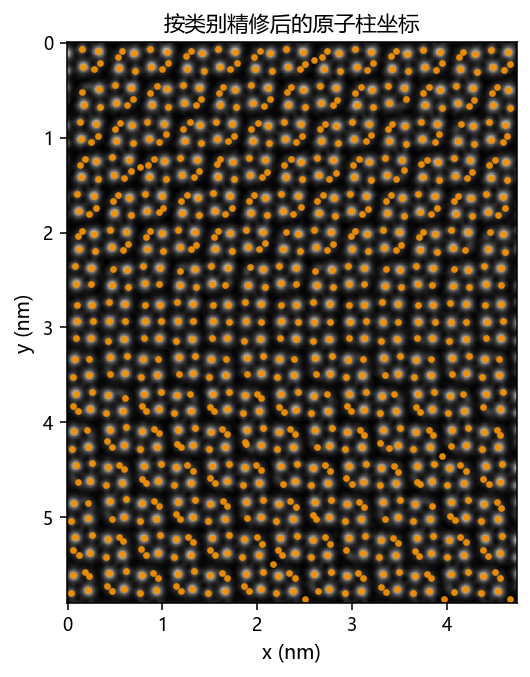

refined_count: 944
refinement_config_sources: ['class_0', 'class_1', 'class_2']
nn_context_mode: all


In [50]:
result = run_generic_refinement(
    session,
    result_root=RESULT_ROOT,
    refinement_config=REFINEMENT_CONFIG,
    class_refinement_overrides=CLASS_REFINEMENT_OVERRIDES,
    source_table='candidate',
    nn_context_mode=NN_CONTEXT_MODE,
)
session = result.session
active_path = result.active_path
display_notebook_result(result)

## 可选：napari 查看精修结果

这一格只读显示精修后的 `refined_points`，可选择同时显示精修前 `candidate_points` 作为对照；关闭 napari 不会写回或改变 session。

In [51]:
# 是否打开 napari 查看精修结果。
OPEN_REFINEMENT_REVIEW_VIEWER = True

# 是否同时显示原始图像层；默认 False，只显示 processed 图像。
SHOW_RAW_LAYER_IN_REFINEMENT_REVIEW = False

# 是否同时显示精修前的 candidate_points 作为对照。
SHOW_CANDIDATE_LAYER_IN_REFINEMENT_REVIEW = True

# napari 中 refined/candidate 点的显示大小。
REFINEMENT_REVIEW_POINT_SIZE = 5.0

if OPEN_REFINEMENT_REVIEW_VIEWER:
    if session is None or session.refined_points.empty:
        raise RuntimeError('refined_points 为空；请先运行上一格亚像素精修。')
    viewer = launch_refinement_napari_viewer(
        session,
        show_raw_layer=SHOW_RAW_LAYER_IN_REFINEMENT_REVIEW,
        show_candidate_layer=SHOW_CANDIDATE_LAYER_IN_REFINEMENT_REVIEW,
        point_size=REFINEMENT_REVIEW_POINT_SIZE,
    )
    viewer.show(block=True)
else:
    print('如需打开 napari 查看精修结果，请设置 OPEN_REFINEMENT_REVIEW_VIEWER = True 后重跑本格。')

## 7. 最终筛选参数

这一格只调整最终自动筛选规则，例如重复点、边缘点、低质量拟合点和最小间距。

In [ ]:
# Curation 参数：用于最终标记重复点、边缘点和低质量拟合点。
CURATION_CONFIG = CurationConfig(
    duplicate_radius_px=1.2,
    edge_margin=6,
    min_quality_score=0.2,
    max_fit_residual=0.30,
    min_spacing_px=None,
    auto_drop_duplicates=False,
    auto_drop_edge_points=False,
    auto_drop_poor_fits=False,
)

## 最终自动筛选与保存

这一步在带类别字段的坐标表上执行最终 curation，添加 `keep` 和质量标记，并刷新 active session 供后续 notebook 使用。

In [52]:
result = run_generic_curation(
    session,
    result_root=RESULT_ROOT,
    curation_config=CURATION_CONFIG,
)
session = result.session
active_path = result.active_path
display_notebook_result(result)

NameError: name 'CURATION_CONFIG' is not defined

## 8. checkpoint 参数

这一格只控制最终 checkpoint 是否额外保存，以及保存文件名。active session 会始终用于后续 notebook 串联。

In [53]:
# SAVE_FINAL_CHECKPOINT：是否在 curated 完成后保存最终 checkpoint。
SAVE_FINAL_CHECKPOINT = True
FINAL_CHECKPOINT_FILENAME = '01_curated_classified_atom_columns.pkl'

## 最终 checkpoint

默认 active session 已经足够传递给后续 notebook；这里额外保存一个明确命名的最终 checkpoint，便于回溯。

In [54]:
result = save_final_checkpoint_if_requested(
    session,
    result_root=RESULT_ROOT,
    filename=FINAL_CHECKPOINT_FILENAME,
    enabled=SAVE_FINAL_CHECKPOINT,
)
display_notebook_result(result)

Current stage is 'classified'; finish refinement/curation first.
